# 1. Initialization

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
N_SAMPLES = 1000
k = 4

In [24]:
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def predict(X, w):
    return X @ w

def fit_ols(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

# Ridge Regression: w = (X^T X + alpha * I)^(-1) X^T y
def fit_ridge(X, y, alpha=10.0):
    I = np.eye(X.shape[1])
    I[0, 0] = 0.0
    return np.linalg.inv(X.T @ X + alpha * I) @ X.T @ y

# Lasso Regression
def fit_lasso(X, y, alpha=0.1, max_iter=1000, tol=1e-4):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)

    def soft_threshold(rho, lmbda):
        if rho < -lmbda:
            return rho + lmbda
        elif rho > lmbda:
            return rho - lmbda
        else:
            return 0.0

    for _ in range(max_iter):
        w_old = w.copy()
        for j in range(n_features):
            y_pred = X @ w
            residual = y - y_pred + w[j] * X[:, j]
            rho = X[:, j].T @ residual

            if j == 0:
                w[j] = rho / (np.sum(X[:, j] ** 2) + 1e-15)
            else:
                w[j] = soft_threshold(rho, alpha * n_samples) / (np.sum(X[:, j] ** 2) + 1e-15)

        if np.max(np.abs(w - w_old)) < tol:
            break
    return w

def k_fold_split(n_samples, k=5, shuffle=True):
    indices = np.arange(n_samples)
    if shuffle:
        np.random.shuffle(indices)
    folds = np.array_split(indices, k)
    splits = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        splits.append((train_idx, val_idx))
    return splits

In [25]:
# 1. Prepare dataset
housing = fetch_california_housing()
X_all = housing.data
y_all = housing.target

idx = np.random.choice(len(X_all), size=N_SAMPLES, replace=False)
X_sub, y_sub = X_all[idx], y_all[idx]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.3, random_state=42)

# 2. Polinomial feature gen
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_raw)
X_test_poly = poly.transform(X_test_raw)

# 3. StandardScale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# 4. Adding bias
X_train = add_bias(X_train_scaled)
X_test = add_bias(X_test_scaled)

print(f"Sample size: {X_train.shape[0]}, Features: {X_train.shape[1]}")

Sample size: 700, Features: 45


# 2. Lasso, Ridge, OLS

In [26]:
# Train & Score
w_ols = fit_ols(X_train, y_train)
w_ridge = fit_ridge(X_train, y_train, alpha=25.0)
w_lasso = fit_lasso(X_train, y_train, alpha=0.08)

# Predict
pred_train_ols, pred_test_ols = X_train @ w_ols, X_test @ w_ols
pred_train_ridge, pred_test_ridge = X_train @ w_ridge, X_test @ w_ridge
pred_train_lasso, pred_test_lasso = X_train @ w_lasso, X_test @ w_lasso

print("\n--- MODEL COMPARISON ---")
print(f"OLS (Overfit)  | Train MSE: {mean_squared_error(y_train, pred_train_ols):.4f} | Test MSE: {mean_squared_error(y_test, pred_test_ols):.4f}")
print(f"Ridge (L2 Fix) | Train MSE: {mean_squared_error(y_train, pred_train_ridge):.4f} | Test MSE: {mean_squared_error(y_test, pred_test_ridge):.4f}")
print(f"Lasso (L1 Fix) | Train MSE: {mean_squared_error(y_train, pred_train_lasso):.4f} | Test MSE: {mean_squared_error(y_test, pred_test_lasso):.4f}")

print(f"\nNumber of w = 0 (OLS):   {np.sum(np.isclose(w_ols, 0))}")
print(f"Number of w = 0 (Lasso): {np.sum(np.isclose(w_lasso, 0, atol=1e-3))} / {len(w_lasso)}")




--- MODEL COMPARISON ---
OLS (Overfit)  | Train MSE: 0.3301 | Test MSE: 0.7699
Ridge (L2 Fix) | Train MSE: 0.4165 | Test MSE: 0.4354
Lasso (L1 Fix) | Train MSE: 0.5667 | Test MSE: 0.6225

Number of w = 0 (OLS):   0
Number of w = 0 (Lasso): 38 / 45


# 3. Elastic Net

In [27]:
def fit_loss_penalty(X, y, alpha1=0.04, alpha2=10.0, max_iter=1000, tol=1e-4):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)

    def soft_threshold(rho, lmbda):
        if rho < -lmbda:
            return rho + lmbda
        elif rho > lmbda:
            return rho - lmbda
        else:
            return 0.0

    for _ in range(max_iter):
        w_old = w.copy()
        for j in range(n_features):
            y_pred = X @ w
            residual = y - y_pred + w[j] * X[:, j]
            rho = X[:, j].T @ residual

            if j == 0:

                w[j] = rho / (np.sum(X[:, j] ** 2) + 1e-15)
            else:

                denominator = np.sum(X[:, j] ** 2) + 2 * alpha2 * n_samples + 1e-15
                w[j] = soft_threshold(rho, alpha1 * n_samples) / denominator

        if np.max(np.abs(w - w_old)) < tol:
            break
    return w

w_loss_penalty = fit_loss_penalty(X_train, y_train, alpha1=0.04, alpha2=10.0)
pred_test_loss_penalty = predict(X_test, w_loss_penalty)
print(f"Loss Penalty Test MSE: {mean_squared_error(y_test, pred_test_loss_penalty):.4f}")

Loss Penalty Test MSE: 1.1391


# 4. Early Stopping

In [28]:
def fit_early_stopping(X, y, lr=0.01, max_epochs=3000, patience=25, val_ratio=0.25):
    val_size = int(len(X) * val_ratio)
    indices = np.random.permutation(len(X))
    tr_idx, val_idx = indices[val_size:], indices[:val_size]

    X_tr, y_tr = X[tr_idx], y[tr_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    w = np.zeros(X.shape[1])
    best_w = w.copy()
    best_loss = float("inf")
    patience_counter = 0

    for epoch in range(max_epochs):
        grad = - (2 / len(X_tr)) * (X_tr.T @ (y_tr - X_tr @ w))
        w -= lr * grad

        val_loss = mean_squared_error(y_val, X_val @ w)
        if val_loss < best_loss:
            best_loss = val_loss
            best_w = w.copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    return best_w

w_early_stopping = fit_early_stopping(X_train, y_train, lr=0.005, patience=30)
pred_test_es = predict(X_test, w_early_stopping)
print(f"Early Stopping Test MSE: {mean_squared_error(y_test, pred_test_es):.4f}")

Early Stopping Test MSE: 0.4203


# 5. K-fold Cross-Validation

In [29]:
# K-fold CV + Ridge / Lasso
splits = k_fold_split(n_samples=len(X_train), k=k, shuffle=True)

candidate_alphas = np.logspace(-2, 2, 20)  # 0.01 to 100
ridge_cv_errors = []
lasso_cv_errors = []

for alpha in candidate_alphas:
    ridge_fold_errors = []
    lasso_fold_errors = []

    for train_idx, val_idx in splits:
        # Train-validation split
        X_tr_fold, y_tr_fold = X_train[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]

        # Fit & validate Ridge
        w_ridge_fold = fit_ridge(X_tr_fold, y_tr_fold, alpha=alpha)
        val_pred_ridge = predict(X_val_fold, w_ridge_fold)
        ridge_fold_errors.append(mean_squared_error(y_val_fold, val_pred_ridge))

        # Fit & validate Lasso
        w_lasso_fold = fit_lasso(X_tr_fold, y_tr_fold, alpha=alpha)
        val_pred_lasso = predict(X_val_fold, w_lasso_fold)
        lasso_fold_errors.append(mean_squared_error(y_val_fold, val_pred_lasso))

    ridge_cv_errors.append(np.mean(ridge_fold_errors))
    lasso_cv_errors.append(np.mean(lasso_fold_errors))

best_alpha_ridge = candidate_alphas[np.argmin(ridge_cv_errors)]
best_alpha_lasso = candidate_alphas[np.argmin(lasso_cv_errors)]

print(f"\nBest Ridge Alpha: {best_alpha_ridge:.4f} (Min CV MSE: {min(ridge_cv_errors):.4f})")
print(f"Best Lasso Alpha: {best_alpha_lasso:.4f} (Min CV MSE: {min(lasso_cv_errors):.4f})")

w_ridge_best = fit_ridge(X_train, y_train, alpha=best_alpha_ridge)
w_lasso_best = fit_lasso(X_train, y_train, alpha=best_alpha_lasso)

tuned_ridge_test_err = mean_squared_error(y_test, predict(X_test, w_ridge_best))
tuned_lasso_test_err = mean_squared_error(y_test, predict(X_test, w_lasso_best))

print("\n--- TUNED MODEL TEST RESULTS ---")
print(f"Test MSE with Tuned Ridge: {tuned_ridge_test_err:.4f}")
print(f"Test MSE with Tuned Lasso: {tuned_lasso_test_err:.4f}")


Best Ridge Alpha: 37.9269 (Min CV MSE: 0.4868)
Best Lasso Alpha: 0.0162 (Min CV MSE: 0.5085)

--- TUNED MODEL TEST RESULTS ---
Test MSE with Tuned Ridge: 0.4470
Test MSE with Tuned Lasso: 0.4700


In [30]:
# K-fold CV + Elastic Net
candidate_a1 = [0.01, 0.04, 0.08]
candidate_a2 = [5.0, 15.0, 30.0]

elastic_cv_results = []

for a1 in candidate_a1:
    for a2 in candidate_a2:
        fold_mses = []
        for train_idx, val_idx in splits:
            X_tr_f, y_tr_f = X_train[train_idx], y_train[train_idx]
            X_val_f, y_val_f = X_train[val_idx], y_train[val_idx]

            w_f = fit_loss_penalty(X_tr_f, y_tr_f, alpha1=a1, alpha2=a2)
            fold_mses.append(mean_squared_error(y_val_f, predict(X_val_f, w_f)))

        elastic_cv_results.append((np.mean(fold_mses), a1, a2))

best_cv_mse, best_a1, best_a2 = min(elastic_cv_results, key=lambda item: item[0])
print(f"Best K-Fold Elastic Net: alpha1={best_a1}, alpha2={best_a2} (CV MSE: {best_cv_mse:.4f})")

w_kfold_elastic = fit_loss_penalty(X_train, y_train, alpha1=best_a1, alpha2=best_a2)
pred_test_kfold_elastic = predict(X_test, w_kfold_elastic)
test_mse_kfold_elastic = mean_squared_error(y_test, pred_test_kfold_elastic)

print(f"K-Fold Elastic Net Test MSE: {test_mse_kfold_elastic:.4f}")

Best K-Fold Elastic Net: alpha1=0.01, alpha2=5.0 (CV MSE: 0.8704)
K-Fold Elastic Net Test MSE: 0.9520


In [31]:
# K-fold Ensemble (K-fold + Elastic Net + Early Stopping)
def fit_elastic_early_stopping(X_tr, y_tr, X_val, y_val, alpha1=0.02, alpha2=10.0,
                               lr=0.002, max_epochs=3000, patience=60):
    n = len(X_tr)
    w = np.zeros(X_tr.shape[1])
    best_w = w.copy()
    best_val_loss = float("inf")
    patience_cnt = 0

    for epoch in range(max_epochs):
        # 1. Gradient
        grad_mse = -(2 / n) * (X_tr.T @ (y_tr - X_tr @ w))
        grad_l2 = 2 * alpha2 * w
        grad_l2[0] = 0.0  # Không phạt bias term

        w -= lr * (grad_mse + grad_l2)

        # 2. Proximal Operator
        threshold = lr * alpha1
        w_features = np.sign(w[1:]) * np.maximum(0, np.abs(w[1:]) - threshold)
        w[1:] = w_features

        # 3. Early Stopping
        val_loss = mean_squared_error(y_val, X_val @ w)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_w = w.copy()
            patience_cnt = 0
        else:
            patience_cnt += 1

        if patience_cnt >= patience:
            break

    return best_w

fold_weights_es = []
for train_idx, val_idx in splits:
    X_tr_f, y_tr_f = X_train[train_idx], y_train[train_idx]
    X_val_f, y_val_f = X_train[val_idx], y_train[val_idx]

    w_fold = fit_elastic_early_stopping(
        X_tr_f, y_tr_f, X_val_f, y_val_f,
        alpha1=0.02, alpha2=10.0, lr=0.002, patience=80
    )
    fold_weights_es.append(w_fold)

# Ensemble
w_kfold_elastic_es = np.mean(fold_weights_es, axis=0)
pred_test_kfold_elastic_es = predict(X_test, w_kfold_elastic_es)
test_mse_kfold_elastic_es = mean_squared_error(y_test, pred_test_kfold_elastic_es)

print(f"K-Fold Elastic Net + Early Stopping Test MSE: {test_mse_kfold_elastic_es:.4f}")

K-Fold Elastic Net + Early Stopping Test MSE: 0.9556


# Visualization & Comparison

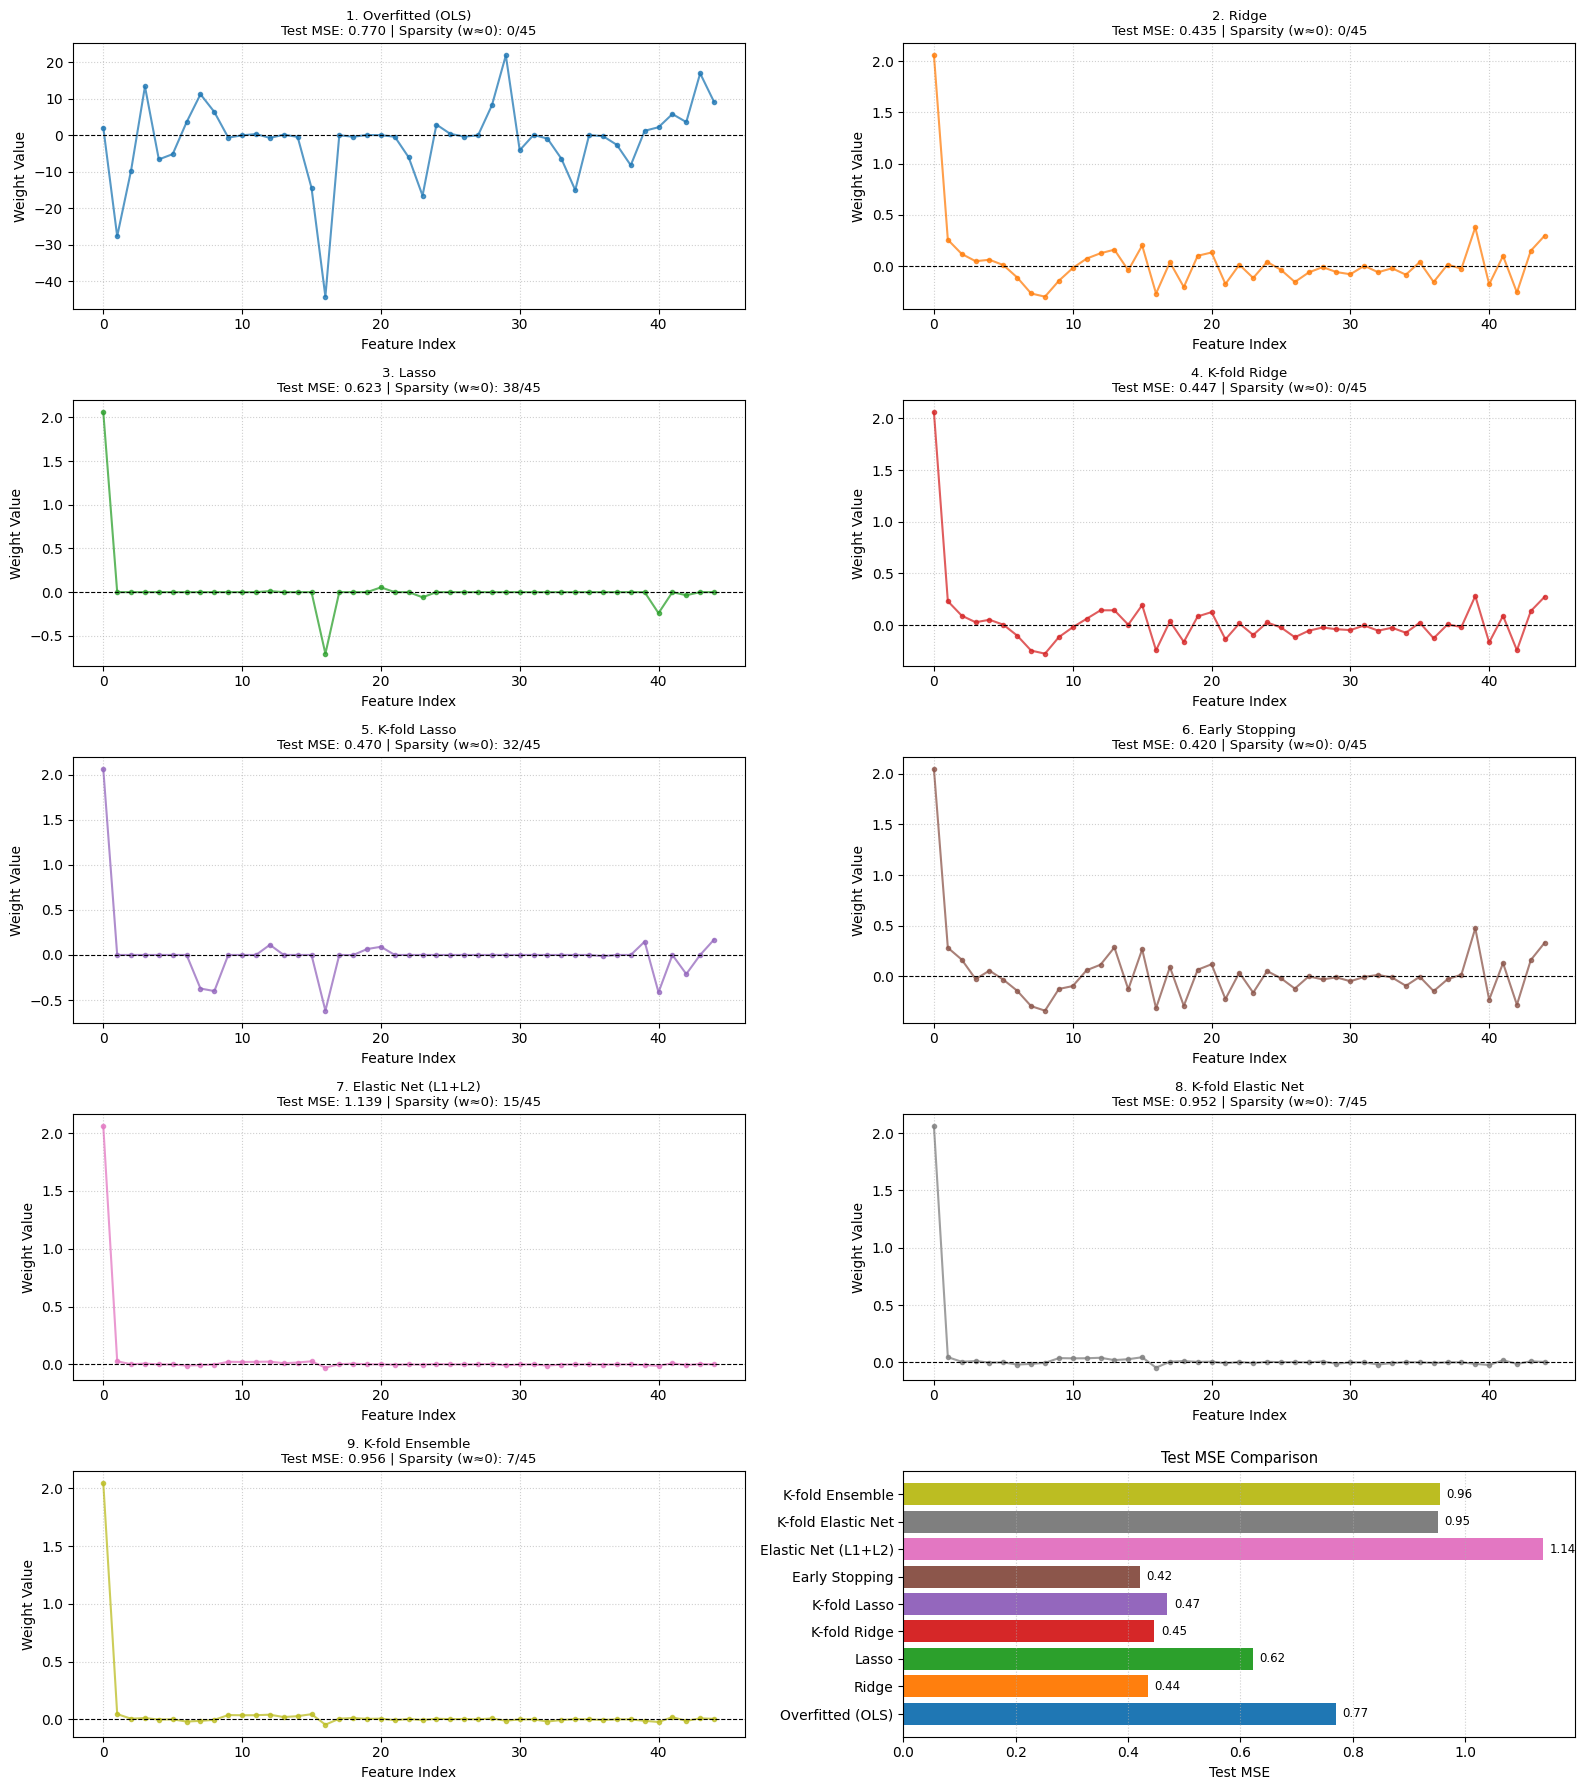

In [32]:
models = {
    "1. Overfitted (OLS)": (w_ols, mean_squared_error(y_test, pred_test_ols)),
    "2. Ridge": (w_ridge, mean_squared_error(y_test, pred_test_ridge)),
    "3. Lasso": (w_lasso, mean_squared_error(y_test, pred_test_lasso)),
    "4. K-fold Ridge": (w_ridge_best, tuned_ridge_test_err),
    "5. K-fold Lasso": (w_lasso_best, tuned_lasso_test_err),
    "6. Early Stopping": (w_early_stopping, mean_squared_error(y_test, pred_test_es)),
    "7. Elastic Net (L1+L2)": (w_loss_penalty, mean_squared_error(y_test, pred_test_loss_penalty)),
    "8. K-fold Elastic Net": (w_kfold_elastic, test_mse_kfold_elastic),
    "9. K-fold Ensemble": (w_kfold_elastic_es, test_mse_kfold_elastic_es)
}

fig, axes = plt.subplots(5, 2, figsize=(16, 18))
axes = axes.flatten()

# Weights
for idx, (name, (w_val, test_mse)) in enumerate(models.items()):
    ax = axes[idx]
    ax.plot(w_val, 'o-', markersize=3, alpha=0.75, color=f"C{idx}")
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    n_zeros = np.sum(np.isclose(w_val, 0, atol=1e-3))
    ax.set_title(f"{name}\nTest MSE: {test_mse:.3f} | Sparsity (w≈0): {n_zeros}/{len(w_val)}", fontsize=9.5)
    ax.set_xlabel("Feature Index")
    ax.set_ylabel("Weight Value")
    ax.grid(True, linestyle=':', alpha=0.6)

# Comparison
ax_comp = axes[9]
model_names = [k.split(". ")[-1] for k in models.keys()]
mses = [v[1] for v in models.values()]
colors = [f"C{i}" for i in range(len(model_names))]

bars = ax_comp.barh(model_names, mses, color=colors)
ax_comp.set_xlabel("Test MSE")
ax_comp.set_title("Test MSE Comparison", fontsize=10.5)
ax_comp.grid(True, axis='x', linestyle=':', alpha=0.6)

for bar in bars:
    val = bar.get_width()
    ax_comp.text(val + max(mses)*0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
                 va='center', fontsize=8.5)

plt.tight_layout()
plt.show()

--- 5 DÒNG ĐẦU TIÊN CỦA TẬP MẪU ĐÃ CHỌN ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price (Target)
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


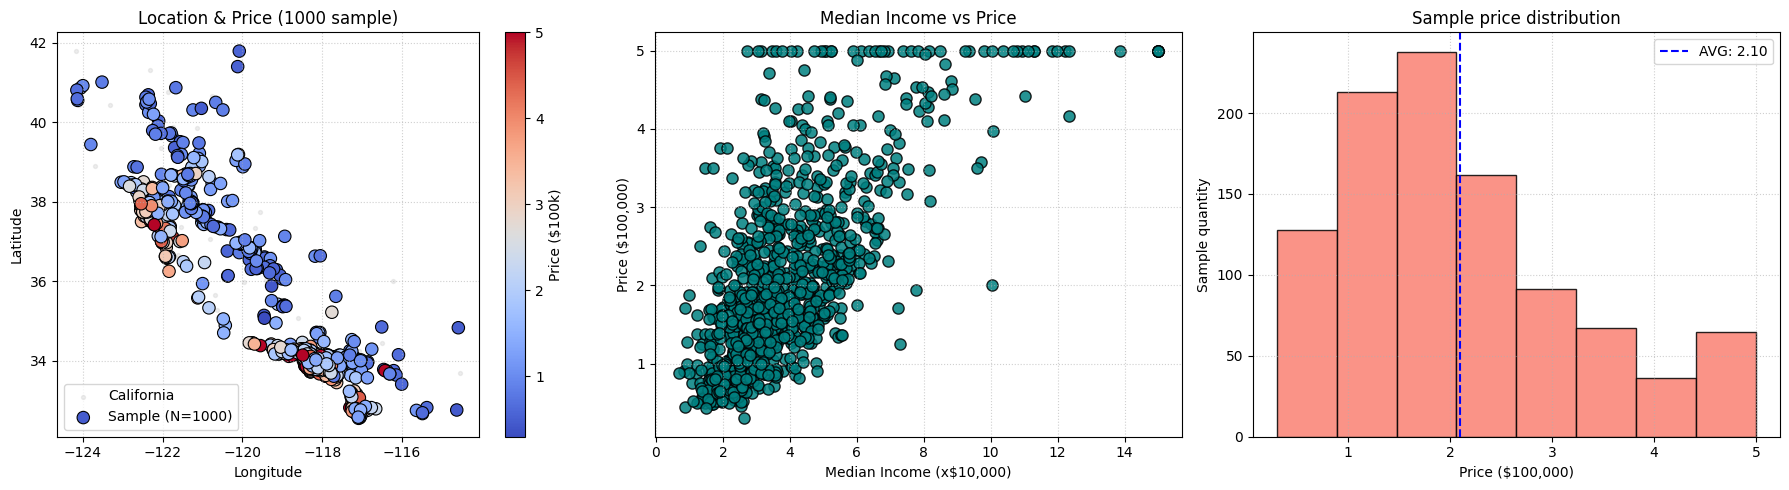

In [33]:
# Visualize Dataset
import pandas as pd

feature_names = housing.feature_names
df_sub = pd.DataFrame(X_sub, columns=feature_names)
df_sub['Price (Target)'] = y_sub

print("--- 5 DÒNG ĐẦU TIÊN CỦA TẬP MẪU ĐÃ CHỌN ---")
display(df_sub.head())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_all[::50, 7], X_all[::50, 6], c='lightgray', s=8, alpha=0.4, label='California')

scatter = axes[0].scatter(df_sub['Longitude'], df_sub['Latitude'],
                          c=df_sub['Price (Target)'], cmap='coolwarm',
                          s=80, edgecolor='black', linewidth=0.8, label=f'Sample (N={len(X_sub)})')
axes[0].set_title(f"Location & Price ({len(X_sub)} sample)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
cbar = fig.colorbar(scatter, ax=axes[0])
cbar.set_label('Price ($100k)')
axes[0].legend(loc='lower left')
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].scatter(df_sub['MedInc'], df_sub['Price (Target)'], c='teal', edgecolor='black', s=65, alpha=0.85)
axes[1].set_title("Median Income vs Price")
axes[1].set_xlabel("Median Income (x$10,000)")
axes[1].set_ylabel("Price ($100,000)")
axes[1].grid(True, linestyle=':', alpha=0.6)

axes[2].hist(df_sub['Price (Target)'], bins=8, color='salmon', edgecolor='black', alpha=0.85)
axes[2].axvline(df_sub['Price (Target)'].mean(), color='blue', linestyle='--', linewidth=1.5,
                label=f"AVG: {df_sub['Price (Target)'].mean():.2f}")
axes[2].set_title("Sample price distribution")
axes[2].set_xlabel("Price ($100,000)")
axes[2].set_ylabel("Sample quantity")
axes[2].legend()
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()